# Phase 2a-1. Macrophage subset & TAM subtype annotation

Phase 1에서 전체 폐암 scRNA-seq 데이터를 QC, normalization, HVG, PCA, Harmony, UMAP, Leiden, cell type annotation까지 완료했다.

이번 notebook의 목적은 전체 immune/TME cell 중 **Macrophage만 subset**한 뒤, macrophage 내부의 TAM subtype(C1QC+ TAM, SPP1+ TAM, ISG15+ TAM)을 marker gene 기반으로 확인하는 것이다.

핵심 질문:
- GSE127465 폐암 데이터에서도 논문에서 제시한 C1QC+ TAM / SPP1+ TAM 패턴이 보이는가?
- 단일 폐암 데이터에서 ISG15+ TAM도 독립적으로 분리되는가?


## 0. Helper — AnnData 상태 검증 함수

단순히 plot이 나오는지만 보는 것이 아니라, 각 단계에서 `adata/mac` 내부 상태가 의도대로 바뀌었는지 확인한다.

확인 항목:
- `shape`: 세포 수 × 유전자 수
- `X` type/dtype: sparse/float32 유지 여부
- `obs/var` unique: barcode/gene 중복 여부
- `obsm/obsp/uns`: PCA, UMAP, neighbors graph 저장 여부
- 주요 obs 컬럼 존재 여부


In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
from utils.paths import *
from utils.report import ph2_report_adata_state

## 1. Phase 1 결과 불러오기

Phase 1에서 이미 전체 cell type annotation까지 완료한 `GSE127465_human_final.h5ad`를 불러온다.

여기서의 `cell_type`은 전체 기준 annotation이고, Phase 2에서는 Macrophage 내부를 다시 세분화해 `tam_subtype`을 추가한다.


In [2]:
adata = sc.read_h5ad(HUMAN_H5AD)
ph2_report_adata_state(adata, 'Phase 1 annotated data')
print(adata.obs['cell_type'].value_counts())

===== Phase 1 annotated data =====
shape: 44,860 cells x 2,000 genes
X type: <class 'numpy.ndarray'>
X dtype: float64
obs names unique: True
var names unique: True
obs columns: ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'n_counts', 'sample', 'leiden', 'cell_type']
obsm keys: ['X_pca', 'X_pca_harmony', 'X_umap']
obsp keys: ['connectivities', 'distances']
layers keys: ['counts']
uns keys: ['cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap']

cell_type
Unknown        14937
T cell         12705
Macrophage      9567
B cell          4572
Cancer cell     3079
Name: count, dtype: int64


## 2. 왜 Macrophage만 subset해서 재클러스터링하는가?

전체 cell 상태에서는 T cell, B cell, epithelial/tumor cell, macrophage 같은 큰 cell type 차이가 PCA/neighbor graph의 주요 variance를 차지한다.

하지만 Phase 2에서 보고 싶은 것은 macrophage 내부의 subtype 차이(C1QC+ TAM vs SPP1+ TAM)다. 전체 cell 기준 embedding에서는 이런 미세한 macrophage 내부 signal이 큰 cell type variance에 묻힐 수 있다.

따라서 Macrophage만 subset한 뒤 PCA/neighbor/UMAP/Leiden을 다시 수행하여 **macrophage 내부 구조에 최적화된 embedding space**를 새로 만든다.

단순히 전체 데이터에서 resolution만 올리는 방식은 graph 자체가 전체 cell 기준으로 만들어진 상태이기 때문에 `noise cluster`, `fragmented cluster`, `meaningless tiny cluster`를 늘릴 위험이 있다.


In [3]:
mac = adata[adata.obs['cell_type'] == 'Macrophage'].copy()
ph2_report_adata_state(mac, 'Macrophage subset')
print(mac.obs['cell_type'].value_counts())

===== Macrophage subset =====
shape: 9,567 cells x 2,000 genes
X type: <class 'numpy.ndarray'>
X dtype: float64
obs names unique: True
var names unique: True
obs columns: ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'n_counts', 'sample', 'leiden', 'cell_type']
obsm keys: ['X_pca', 'X_pca_harmony', 'X_umap']
obsp keys: ['connectivities', 'distances']
layers keys: ['counts']
uns keys: ['cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap']

cell_type
Macrophage    9567
Name: count, dtype: int64


### 2-1. Macrophage subset 전용 HVG/PCA/Harmony 재계산
mac.obsm['X_pca_harmony']가 Phase1에서 계산된 전체 cell 기준 좌표를 그대로 보유하고 있음을 발견했다
(mac.uns['pca']['variance_ratio']가 전체 데이터 기준 분포와 동일).  
Macrophage subtype 간 차이는 전체 cell type 간 차이보다 미세하므로 subset 전용으로 HVG -> PCA -> Harmony를 재계산 해야 함

#### 1차 시도 - fail
mac.X를 그대로 두고 sc.pp.highly_variable_genes()를 호출했으나 다음 문제 발생:  
- RuntimeWarnning: invalid value encountered in log  
- mac.var['means'].describe() 에서 음수 mean값 확인 (정상이라면 발현량은 0 이상이어야 함)  
- 발현되는 gene 수가 552/2000 으로 비정상적으로 작음

원인 규명: mac.X가 Phase1에서 sc.pp.scale(max_value=10)까지 거친 scaled(z-score) matrix였다. Scaled 행렬 위에서 HVG dispersion을 계산하여 했기 때문에 발생한 문제이다.

근본적인 원인:  
Phase1 파이프라인 구조: normalize_total -> log1p -> (HVG 계산) -> adata.raw = adata backup -> HVG subset -> scale -> PCA  
adata.raw에는 scale 이전(log-normalized) 상태가 보존되어 있었으나, Phase2에서 subset 직후 이 raw를 사용하지 않고 이미 scale된 adata.X로 바로 HVG를 재계산하려 한 것이 원인이다.

#### 2차 발견 - mac.raw도 오염되어 있었음
1차 시도 수정을 위해 mac.raw.to_adata()로 복구를 시도했으나, mac.raw 자체가 이상한 시점(HVG 계산 직후, log-normalized)이 아니라 var_names가 2000개(HVG subset 이후)이고 varm에 'PCs'까지 포함된 상태였다.  

원인: Phase1 노트북에서 annotation 단계 marker gene 조회를 위해 `adata.raw = adata`를 한 번 더 호출한 부분이 있었음. 이 시점은 이미 HVG subset + scale + PCA가 끝난 뒤였기 때문에, 의도(전체 유전자 백업)와 달리 두 번째 호출이 첫 번째 raw 백업(log-normalized, 41861 genes)을 덮어써 버렸다.  

결론: 메모리/저장된 h5ad 모두 raw가 신뢰 불가능한 상태였으므로, QC 완료 시점부터 normalize_total -> log1p까지 재현한 뒤 별도 파일(`RAW_LOGNORM_H5AD`)로 저장하고, 이 시점에서 `adata.raw = adata`를 단 한 번만 실행하도록 재구성했다. Phase1 annotation 결과(`cell_type`)는 barcode 기준으로 새 adata에 다시 매핑했다.

In [4]:
# 0. raw가 정상 시점(log-normalized, scale 이전)인지 확인
assert adata.raw is not None
print(adata.raw.shape)  # (44860, 41861) — 전체 gene이어야 정상
print(adata.raw.X.min(), adata.raw.X.max())  # 0 이상이어야 정상

# 1. macrophage subset
mac = adata[adata.obs['cell_type'] == 'Macrophage'].copy()
print(mac.shape)
print(mac.raw.shape)
print(mac.raw.X.min(), mac.raw.X.max())

# 2. raw에서 log-normalized 전체 gene 복구
mac_full = mac.raw.to_adata()
mac_full.obs = mac.obs.copy()
mac = mac_full
print(mac.shape)
print(mac.X.min(), mac.X.max())  # 0 이상이어야 정상

# 3. subset 안에서 거의 발현 안 되는 gene 제거
sc.pp.filter_genes(mac, min_cells=3)
print(mac.shape)

(44860, 41861)
0.0 8.966066
(9567, 2000)
(9567, 41861)
0.0 8.185986
(9567, 41861)
0.0 8.185986
(9567, 32634)


이후 subset 전용 filter_genes -> highly_variable_genes -> scale(PCA 입력용으로만) -> PCA -> Harmony 순서로 재계산한다. mac.X는 log-normalized 상태로 유지하고 scale은 PCA 계산용 임시 객체에만 적용해 marker visualization(score_genes, dotplot)이 scaled 값이 아닌 해석 가능한 log-normalized 값을 사용하도록 한다.  

강조 하고 싶은 점:  
subset 후 재클러스터링 시 X가 어느 전처리 단계의 값을 담고있는지 (raw count / log-normalized / scaled) 반드시 먼저 확인해야 한다. scanpy의 adata.raw는 scale 이전 시점을 보존하는 용도이므로, subset 후 HVG/PCA를 다시 계산할 때는 .raw에서 시작하는 것이 표준이다.

In [5]:
sc.pp.highly_variable_genes(mac, n_top_genes=2000, batch_key='sample')
print('HVG count:', mac.var['highly_variable'].sum())
print('NaN in dispersions_norm:', mac.var['dispersions_norm'].isna().sum())
print(mac.var['means'].describe())  # min이 0 이상이어야 정상

HVG count: 2000
NaN in dispersions_norm: 0
count    32634.000000
mean         0.135819
std          0.311866
min          0.000135
25%          0.003558
50%          0.017021
75%          0.133838
max          4.845555
Name: means, dtype: float64


## 3. Macrophage subset 재클러스터링

Phase 1에서 생성된 Harmony 보정 PCA embedding(`X_pca_harmony`)을 사용하여 macrophage subset 내부에서 neighbor graph를 다시 만든다.

function 설명:
- `neighbors`: 세포 간 graph 저장 단계
- `umap`: graph 기반 2D 시각화
- `leiden`: graph 기반 community detection으로 cluster label 생성

재현성 강화:
- `random_state = 42`를 각 단계마다(neighbor, umap, leiden) 부여하게 되면 각 stochastic process가 fix됨
- 결과 variance가 감소하고 return 안정성이 증가함

In [6]:
# PCA 수행
mac_pca_input = mac[:, mac.var['highly_variable']].copy()
sc.pp.scale(mac_pca_input, max_value=10)
sc.pp.pca(mac_pca_input, n_comps=50, random_state=42)

mac.obsm['X_pca'] = mac_pca_input.obsm['X_pca']
mac.uns['pca'] = mac_pca_input.uns['pca']

print(mac.obsm['X_pca'].shape)

c:\Users\82108\anaconda3\envs\spatial\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


(9567, 50)


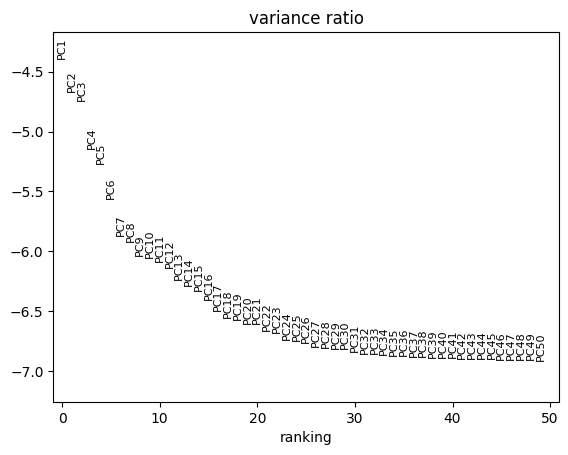

[0.01241704 0.00937899 0.00871218 0.00585453 0.00515271 0.00384572
 0.00281131 0.00267822 0.00238644 0.00234099 0.00227215 0.00216454
 0.00194852 0.00186167 0.00178635 0.00165942 0.00150611 0.00142301
 0.00140154 0.00135623]


In [7]:
sc.pl.pca_variance_ratio(mac, n_pcs=50, log=True)
print(mac.uns['pca']['variance_ratio'][:20])

Elbow 읽기:
- PC1 ~ PC3: 급격히 떨어짐
- PC4 ~ PC6: 한번 더 꺾임
- PC7 ~ PC18: 완만하게 떨어짐
- PC8 ~ PC20 이후: 거의 평평해짐  

육안상 elbow point는 PC15~PC18로 보이나 정확한 수치를 따지기 위해 숫자로 검증해보겠다.

In [9]:
vr = mac.uns['pca']['variance_ratio']
diffs = np.diff(vr)  # 인접 PC 간 variance 감소폭
for i, d in enumerate(diffs[:25], start=1):
    print(f'PC{i} -> PC{i+1}: {d:.5f}')
    
cumsum = np.cumsum(vr)
for i in [10, 15, 17, 20, 25]:
    print(f'PC1~{i} 누적 설명 variance: {cumsum[i-1]*100:.2f}%')

PC1 -> PC2: -0.00304
PC2 -> PC3: -0.00067
PC3 -> PC4: -0.00286
PC4 -> PC5: -0.00070
PC5 -> PC6: -0.00131
PC6 -> PC7: -0.00103
PC7 -> PC8: -0.00013
PC8 -> PC9: -0.00029
PC9 -> PC10: -0.00005
PC10 -> PC11: -0.00007
PC11 -> PC12: -0.00011
PC12 -> PC13: -0.00022
PC13 -> PC14: -0.00009
PC14 -> PC15: -0.00008
PC15 -> PC16: -0.00013
PC16 -> PC17: -0.00015
PC17 -> PC18: -0.00008
PC18 -> PC19: -0.00002
PC19 -> PC20: -0.00005
PC20 -> PC21: -0.00000
PC21 -> PC22: -0.00008
PC22 -> PC23: -0.00002
PC23 -> PC24: -0.00006
PC24 -> PC25: -0.00001
PC25 -> PC26: -0.00002
PC1~10 누적 설명 variance: 5.56%
PC1~15 누적 설명 variance: 6.56%
PC1~17 누적 설명 variance: 6.88%
PC1~20 누적 설명 variance: 7.30%
PC1~25 누적 설명 variance: 7.92%


결과:
PC1 ~ PC7: 유의미한 변화
PC8 이후: 감소폭이 -0.0001 ~ -0.00002 수준에서 미세하게 출렁이며 평평해짐 (기울기가 완만해짐)  

### 누적 variance가 낮은 이유  
: PC1~15 누적 설명 variance: 6.56%, PC1~20 누적 설명 variance: 7.30% -> 정상범주라고 판단  
전체 cell상태 (여러 cell type이 섞인 상태)에서는 cell type의 차이가 워낙 크다보니 PC 몇개로 변동성 대부분을 설명할 수 있으나, macrophage subset은 이미 같은 cell type끼리만 모아놓은거라 남은 변동성 자체가 미세한 차이들로만 이루어져 있어 PC 당 설명력이 낮게 나올 수 있다.  

### n_pcs 후보  
elbow 기준으로는 PC7 전후가 가장 뚜렷한 꺾임포인트이다. -> 7로 채택

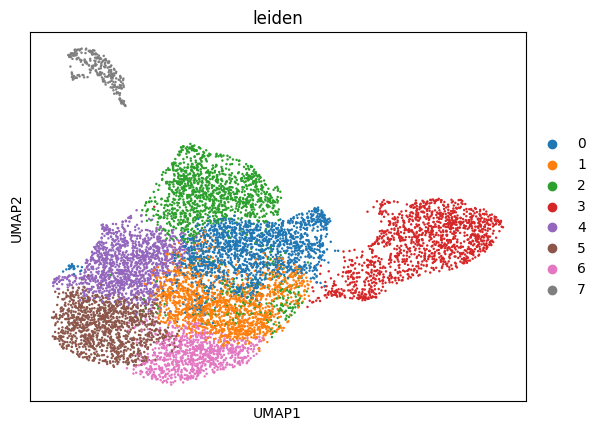

In [15]:
sc.pp.neighbors(mac, use_rep='X_pca', n_pcs=7, random_state=42)
sc.tl.umap(mac, random_state=42)
sc.tl.leiden(mac, resolution=0.5, random_state=42)
sc.pl.umap(mac, color='leiden')

아직 Harmoney를 적용하지 않은 상태의 umap이다.  
현재 n_pcs는 7로 둘 수 있는 정량적 근거가 있지만 resolution은 아직 근거가 없다.  
이유는 harmony를 아직 적용하지 않아 추후 cluster구조가 변동 될 가능성이 있기에 임의의 값을 넣어 돌렸다.  
현재 시각화 된 umap을 본다면 harmoney의 필요성을 시사한다.  
동 떨어진 7번 클러스터나 엄청나게 엉켜있는 3번 제외 나머지 클러스터들이 그 증거이다.  
그렇기에 이젠 harmoney를 진행해보겠다.

In [16]:
# 1. n_pcs=7로 확정 후 Harmony 적용
import harmonypy as hm

pca_result = mac.obsm['X_pca'][:, :7]   # n_pcs=7만 사용
meta = mac.obs[['sample']]
ho = hm.run_harmony(pca_result, meta, 'sample')

Z_corr = ho.Z_corr
if Z_corr.shape[0] != mac.n_obs and Z_corr.shape[1] == mac.n_obs:
    Z_corr = Z_corr.T
assert Z_corr.shape[0] == mac.n_obs

mac.obsm['X_pca_harmony'] = Z_corr
print(mac.obsm['X_pca_harmony'].shape)

2026-06-19 20:46:50,030 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-06-19 20:46:50,030 - harmonypy - INFO -   Parameters:
2026-06-19 20:46:50,031 - harmonypy - INFO -     max_iter_harmony: 10
2026-06-19 20:46:50,031 - harmonypy - INFO -     max_iter_kmeans: 20
2026-06-19 20:46:50,032 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-06-19 20:46:50,033 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-06-19 20:46:50,034 - harmonypy - INFO -     nclust: 100
2026-06-19 20:46:50,034 - harmonypy - INFO -     block_size: 0.05
2026-06-19 20:46:50,035 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1.]
2026-06-19 20:46:50,036 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2.]
2026-06-19 20:46:50,036 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-06-19 20:46:50,037 - harmonypy - INFO -     verbose: True
2026-06-19 20:46:50,037 - harmonyp

(9567, 7)


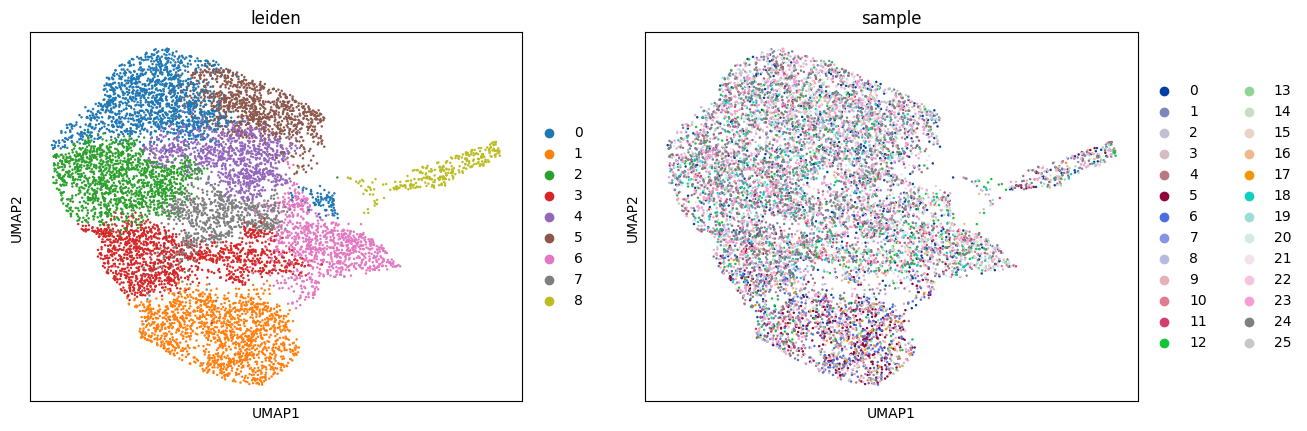

In [17]:
# 2. cluster 7이 batch artifact였는지 확인 (Harmony 후 island가 사라지는지)
sc.pp.neighbors(mac, use_rep='X_pca_harmony', n_pcs=7, random_state=42)
sc.tl.umap(mac, random_state=42)
sc.tl.leiden(mac, resolution=0.5, random_state=42)
sc.pl.umap(mac, color=['leiden', 'sample'])

왼쪽의 umap을 보면 아까 독립적으로 나와있던 7번 클러스터가 사라진 것을 볼 수 있다.  
그리고 오른쪽의 umap을 보면 sample클러스터들이 골고루 섞여있는 것을 볼 수 있다.  

오른쪽 umap이 나타내는 결과는 같은 점들이 어느 sample에서 나온 cell인지 색으로 칠해둔 것이다.  
즉, 제대로 섞여있는 umap을 보아 harmoney batch correction이 가 잘 적용되어있다는 것을 의미한다.  

> Harmony를 적용하기 전이었다면, 같은 환자에서 나온 cell들끼리 UMAP 상에서 뭉쳐 보였을 것이다. 이건 "biological 차이"가 아니라 "실험 batch 차이" 때문에 생기는 인위적인 분리이다. <- batch effect

> Harmony를 적용한 후에는, 이 batch 차이를 수학적으로 제거한다. 그 결과 어떤 sample에서 왔는지가 아닌 어떤 biological state(macrophage subtype)인지 만으로 위치를 결정하게 된다. 결과적으로 umap에 sample 색깔이 전체 공간에 고르게 뒤섞여 보이는 원리이다.  

이번엔 sweep을 돌려서 숫자를 보고 적합한 resolution 값을 찾아보겠다.

In [18]:
from sklearn.metrics import silhouette_score
import pandas as pd

resolutions = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results = []

for res in resolutions:
    sc.tl.leiden(mac, resolution=res, random_state=42, key_added=f'leiden_r{res}')
    n_clusters = mac.obs[f'leiden_r{res}'].nunique()
    if n_clusters > 1:
        sil = silhouette_score(mac.obsm['X_pca_harmony'][:, :7], mac.obs[f'leiden_r{res}'])
    else:
        sil = float('nan')
    results.append({'resolution': res, 'n_clusters': n_clusters, 'silhouette': sil})

res_df = pd.DataFrame(results)
print(res_df)

   resolution  n_clusters  silhouette
0         0.1           4    0.228068
1         0.2           6    0.206171
2         0.3           7    0.225781
3         0.4           8    0.225551
4         0.5           9    0.200277
5         0.6          11    0.152968
6         0.7          12    0.169911
7         0.8          15    0.156457
8         0.9          16    0.149782
9         1.0          20    0.143433


### 결과 분석
전반적으로 resolution이 올라갈 수록 silhouette이 떨어진다.  
이것은 클러스터를 잘게 쪼갤수록 분리도가 흐려진다는 뜻이다.  

- 0.1 ~ 0.4 구간: silhouette이 0.20 ~ 0.23 사이로 높고 안정적이다. 그중 0.3과 0.4가 공동 최고점(0.226)  
- 0.5: 0.200으로 한 단계 떨어짐  
- 0.6 이후: 0.14 ~ 0.17로 뚝 떨어지고 클러스터 수만 계속 늘어남(over-fragmentation 시작)

> silhouette_score에 의하면 가장 적합한 resolution값은 0.3~0.4 이다.  

하지만 아직 0.3과 0.4, 그리고 현재 쓰고 있는 0.5까지 봤을 때, 이 세 후보를 놓고 marker 기준으로 한번 더 확인 해보는 것이 좋다.

--- resolution=0.3 (7 clusters) ---


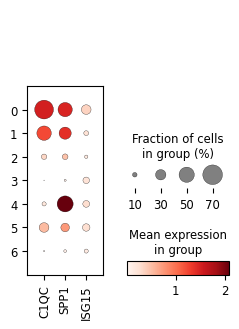

--- resolution=0.4 (8 clusters) ---


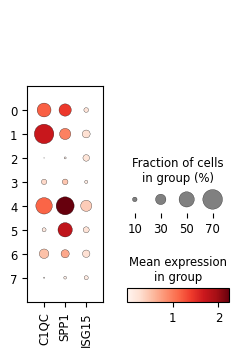

--- resolution=0.5 (9 clusters) ---


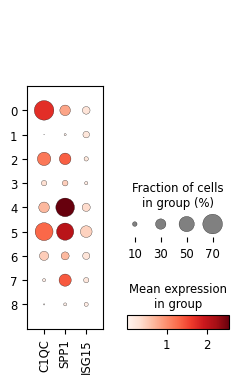

In [19]:
for res in [0.3, 0.4, 0.5]:
    sc.tl.leiden(mac, resolution=res, random_state=42, key_added=f'leiden_r{res}')
    print(f'--- resolution={res} ({mac.obs[f"leiden_r{res}"].nunique()} clusters) ---')
    sc.pl.dotplot(mac, ['C1QC', 'SPP1', 'ISG15'], groupby=f'leiden_r{res}')

In [26]:
# 0.3, 0.4, 0.5 각각에 대해 score 계산 후 cluster별 평균 비교
sc.tl.score_genes(mac, ['C1QC', 'APOE', 'APOC1', 'SELENOP'], score_name='C1QC_score')
sc.tl.score_genes(mac, ['SPP1', 'GPNMB', 'CTSD', 'MRC1', 'CD63'], score_name='SPP1_score')

for res in [0.3, 0.4, 0.5]:
    print(f'--- resolution={res} ---')
    summary = mac.obs.groupby(f'leiden_r{res}')[['C1QC_score', 'SPP1_score']].agg(['mean', 'std', 'count'])
    print(summary)
    print()

--- resolution=0.3 ---
            C1QC_score                 SPP1_score                
                  mean       std count       mean       std count
leiden_r0.3                                                      
0             0.948171  0.884560  2405   1.673276  0.550747  2405
1             0.930090  0.935074  1827   1.795834  0.734895  1827
2            -0.443320  0.563412  1578   0.290727  0.909402  1578
3            -0.949105  0.189844  1434  -0.233049  0.407957  1434
4            -0.633779  0.547364  1097   1.221541  0.994546  1097
5            -0.750635  0.423211   934   0.027381  0.749484   934
6            -0.753695  0.268613   292  -0.440409  0.483637   292

--- resolution=0.4 ---
            C1QC_score                 SPP1_score                
                  mean       std count       mean       std count
leiden_r0.4                                                      
0             0.886505  0.935094  1666   1.796162  0.739383  1666
1             1.186830  0.874

C:\Users\82108\AppData\Local\Temp\ipykernel_3356\3365809499.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = mac.obs.groupby(f'leiden_r{res}')[['C1QC_score', 'SPP1_score']].agg(['mean', 'std', 'count'])
C:\Users\82108\AppData\Local\Temp\ipykernel_3356\3365809499.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = mac.obs.groupby(f'leiden_r{res}')[['C1QC_score', 'SPP1_score']].agg(['mean', 'std', 'count'])
C:\Users\82108\AppData\Local\Temp\ipykernel_3356\3365809499.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. 

In [27]:
res = 0.5
summary = mac.obs.groupby('leiden')[['C1QC_score', 'SPP1_score']].agg(['mean', 'std', 'count'])
print(summary)

       C1QC_score                 SPP1_score                
             mean       std count       mean       std count
leiden                                                      
0        1.197900  0.896880  1534   1.500569  0.636895  1534
1       -0.948096  0.190745  1439  -0.229378  0.411867  1439
2        0.890518  0.959144  1386   1.750499  0.784894  1386
3       -0.436777  0.553377  1357   0.292508  0.913361  1357
4        0.046707  0.878711   973   1.879879  0.606029   973
5        0.646520  0.816751   943   1.774174  0.534714   943
6       -0.773554  0.404031   911  -0.025655  0.719657   911
7       -0.740238  0.435007   730   0.713191  0.994322   730
8       -0.755885  0.269009   294  -0.433845  0.488502   294


C:\Users\82108\AppData\Local\Temp\ipykernel_3356\3873487549.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = mac.obs.groupby('leiden')[['C1QC_score', 'SPP1_score']].agg(['mean', 'std', 'count'])


### Resolution 선택 근거

Silhouette score sweep 결과 resolution=0.3~0.4에서 최고점(0.226)을 보였으나,
해당 resolution에서는 C1QC+ TAM과 SPP1+ TAM core cluster가 명확히 분리되지
않았다. 예를 들어 resolution=0.3의 cluster 0(C1QC_score=0.95, SPP1_score=1.67)과
cluster 1(C1QC_score=0.93, SPP1_score=1.80)은 두 marker score가 거의 동일하여
사실상 동일한 그룹이 인위적으로 분할된 것으로 판단된다.

resolution=0.5에서는 cluster 0(C1QC_score=1.20, SPP1_score=1.50)과
cluster 4(C1QC_score=0.05, SPP1_score=1.88)가 C1QC/SPP1 우세 방향이 뚜렷하게
반대로 갈리며 처음으로 명확히 분리되었다. silhouette score(0.200)는 0.3~0.4
대비 다소 낮지만, 본 연구의 목적(TAM subtype 구분)에 비춰 marker 기반
생물학적 분리도를 우선하여 resolution=0.5를 최종 채택했다.

resolution >= 0.6부터는 silhouette score가 급격히 하락(0.226 -> 0.153)하며
cluster 수만 늘어나는 over-fragmentation 양상을 보여 배제했다.

(검증 방법: sc.tl.score_genes로 C1QC/SPP1 marker set score를 계산한 뒤,
cluster별 평균 score를 비교하여 marker 분리도를 정량 평가했다.)

In [20]:
# Phase 1 annotated 결과 불러오기
adata = sc.read_h5ad(HUMAN_H5AD)

# 같은 PCA/Harmony 좌표에서 resolution만 바꿔서 cell type 경계가 흔들리는지 확인
sc.pp.neighbors(adata, use_rep='X_pca_harmony', n_pcs=17, random_state=42)

for res in [0.3, 0.5, 0.8, 1.0]:
    sc.tl.leiden(adata, resolution=res, random_state=42, key_added=f'leiden_check_{res}')
    n = adata.obs[f'leiden_check_{res}'].nunique()
    print(f'resolution={res}: {n} clusters')

# cross-tab으로 기존 cell_type과 새 cluster가 잘 대응되는지 확인
import pandas as pd
print(pd.crosstab(adata.obs['cell_type'], adata.obs['leiden_check_0.5']))

resolution=0.3: 13 clusters
resolution=0.5: 15 clusters
resolution=0.8: 17 clusters
resolution=1.0: 20 clusters
leiden_check_0.5     0     1     2     3     4     5     6     7     8    9  \
cell_type                                                                     
B cell               0     0     0     0  4572     0     0     0     0    0   
Cancer cell          0     0     0     0     0     0     0  2308     0  771   
Macrophage           0     0  4792  4775     0     0     0     0     0    0   
T cell            9665     0     0     0     0     0  3040     0     0    0   
Unknown              0  6956     0     0     0  4282     0     0  1641    0   

leiden_check_0.5   10   11   12   13   14  
cell_type                                  
B cell              0    0    0    0    0  
Cancer cell         0    0    0    0    0  
Macrophage          0    0    0    0    0  
T cell              0    0    0    0    0  
Unknown           695  548  388  233  194  


### Phase 1 cell type annotation의 resolution 민감도 사후 검증

Phase 2에서 macrophage subset resolution 재검토 중, Phase 1 cell type
annotation도 resolution 선택에 영향받는지 우려가 있어 사후 검증을 진행했다.

동일한 X_pca_harmony(n_pcs=17) 좌표에서 resolution을 0.3~1.0으로 바꿔가며
재클러스터링한 뒤 기존 cell_type과 cross-tab 비교한 결과, 모든 resolution에서
Macrophage/T cell/B cell/Cancer cell 각 cluster는 단일 cell type으로만
구성되었으며 cell type 간 경계가 섞이는 cluster는 없었다. resolution 증가는
각 cell type 내부의 세분화(예: Macrophage가 1개에서 2개 cluster로 분할)로만
이어졌고, 큰 범주의 cell type annotation 자체는 resolution 선택에 안정적임을
확인했다. 따라서 Phase 1 결과는 재작업 없이 그대로 사용한다.

In [24]:
ph2_report_adata_state(mac, 'After macrophage reclustering')
print('Leiden cluster count:', mac.obs['leiden'].nunique())
print(mac.obs['leiden'].value_counts().sort_index())

===== After macrophage reclustering =====
shape: 9,567 cells x 32,634 genes
X type: <class 'scipy.sparse._csr.csr_matrix'>
X dtype: float32
obs names unique: True
var names unique: True
obs columns: ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'n_counts', 'sample', 'leiden', 'cell_type', 'leiden_7', 'leiden_8', 'leiden_9', 'leiden_10', 'leiden_12', 'leiden_15', 'leiden_r0.1', 'leiden_r0.2', 'leiden_r0.3', 'leiden_r0.4', 'leiden_r0.5', 'leiden_r0.6', 'leiden_r0.7', 'leiden_r0.8', 'leiden_r0.9', 'leiden_r1.0']
obsm keys: ['X_pca', 'X_pca_harmony', 'X_umap']
obsp keys: ['connectivities', 'distances', 'nn_7_distances', 'nn_7_connectivities', 'nn_8_distances', 'nn_8_connectivities', 'nn_9_distances', 'nn_9_connectivities', 'nn_10_distances

## 4. TAM subtype marker gene 발현 확인

논문에서 제시한 TAM subtype marker를 기준으로 C1QC+ TAM, SPP1+ TAM, ISG15+ TAM이 macrophage subset 안에서 어디에 위치하는지 확인한다.

- C1QC: tissue-resident/homeostatic macrophage 계열 marker
- SPP1: tumor-associated remodeling / immunosuppressive macrophage 계열 marker
- ISG15: interferon-stimulated macrophage state marker

`mac.X`가 filter_genes(min_cells=3) 이후에도 HVG로 잘리지 않은 32634개 전체 유전자의 log-normalized 값을 그대로 보유하고 있으므로 별도의 `use_raw=True` 없이 `mac.X`에서 직접 marker gene을 조회한다.

Missing markers in mac: []


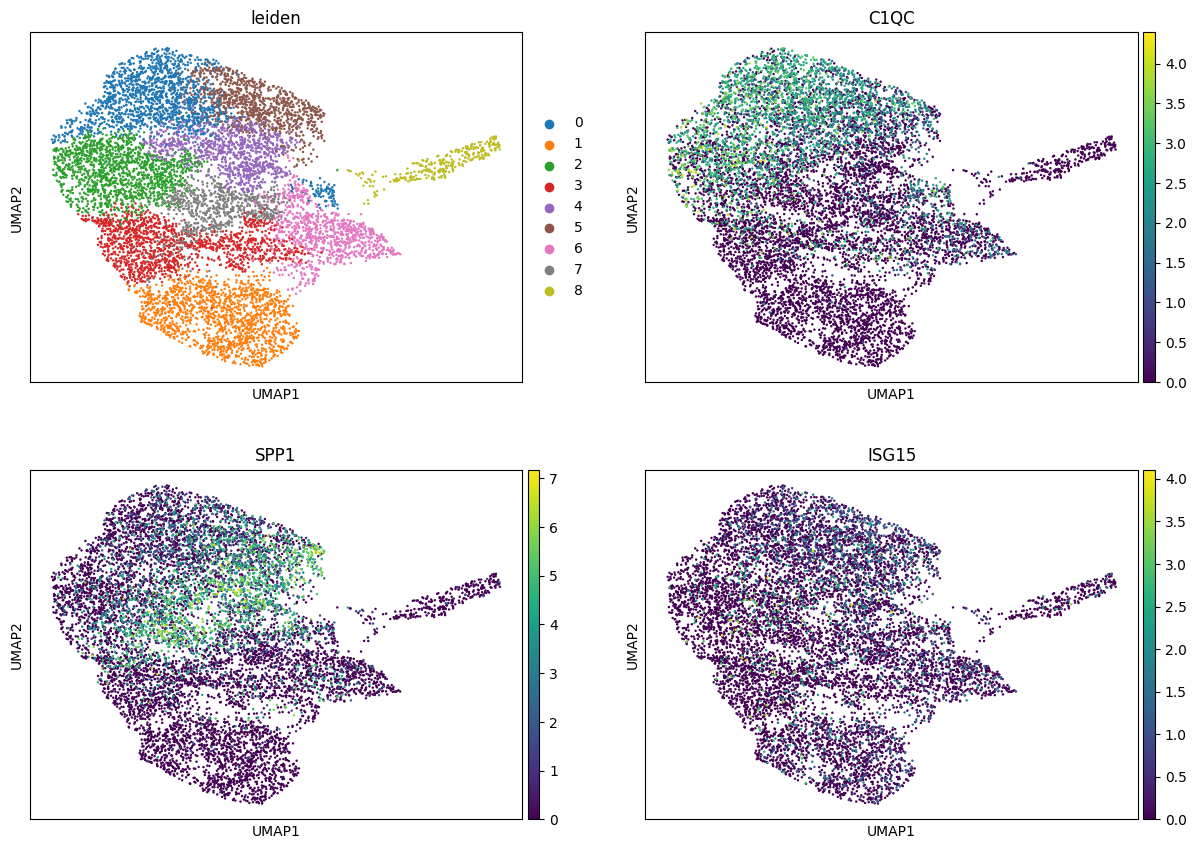

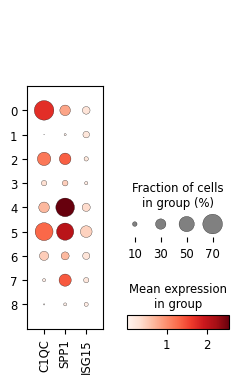

In [29]:
tam_markers = ['C1QC', 'SPP1', 'ISG15']
missing_markers = [g for g in tam_markers if g not in mac.var_names]
print('Missing markers in mac:', missing_markers)

sc.pl.umap(mac, color=['leiden', 'C1QC', 'SPP1', 'ISG15'], ncols=2)
sc.pl.dotplot(mac, tam_markers, groupby='leiden')

## 5. Marker 기반 TAM subtype annotation

UMAP과 dotplot을 함께 확인하여 marker 발현이 뚜렷한 cluster에 TAM subtype label을 부여한다.

annotation base-line을 Fraction of cells or Mean expression?
- 일반적으로는 fraction을 더 우선적으로,
- 후에 mean expression intensity 고려

Fraction of cells:
- 해당 cluster 안에서 몇 %의 세포가 이 유전자를 발현하나?
Mean expression:
- 발현하는 세포들의 평균 발현량이 얼마나 강한가?

현재 기준:
- cluster 0 → C1QC+ TAM
- cluster 4 → SPP1+ TAM
- ISG15+ TAM은 단일 폐암 데이터에서 독립 cluster로 뚜렷하게 분리되지 않아 annotation하지 않음

sub:
- 5 -> C1QC/SPP1 intermediate or mixed TAM
- 7 -> SPP1-like TAM 후보
- 2 -> C1QC-like TAM 후보

issue 발생:
- 5번 cluster가 양쪽 marker에 걸쳐 있음
- 이 cluster들을 단순히 C1QC+ 또는 SPP1+로 확정하는 것이 맞는 건지 의심됨

=> 단일 gene으로 가는 것 보다 ``gene set score``를 보는 방법을 선택

In [34]:
# 논문 Table S3 기준 marker (avg_log2FC 상위, pct.1-pct.2 specificity 고려하여 선정)
# Resting C1QC+ TAMs top marker
resting_c1qc_markers = ["SELENOP", "APOC1", "C1QB", "C1QA", "C1QC"]

# Activated C1QC+ TAMs top marker
activated_c1qc_markers = ["FOLR2", "SLC40A1", "RNASE1", "C1QC"]

# SPP1+ TAMs top marker
spp1_markers = ["FN1", "SPP1", "INHBA", "CXCL3", "FABP5"]

# ISG15+ TAMs top marker
isg15_markers = ["CXCL10", "CXCL11", "CXCL9", "IDO1", "ISG15"]

marker_sets = {
    "Resting C1QC+": resting_c1qc_markers,
    "Activated C1QC+": activated_c1qc_markers,
    "SPP1+": spp1_markers,
    "ISG15+": isg15_markers,
}

for name, genes in marker_sets.items():
    present = [g for g in genes if g in mac.var_names]
    missing = [g for g in genes if g not in mac.var_names]
    print(f"{name} — present: {present}")
    if missing:
        print(f"{name} — MISSING: {missing}")

Resting C1QC+ — present: ['SELENOP', 'APOC1', 'C1QB', 'C1QA', 'C1QC']
Activated C1QC+ — present: ['FOLR2', 'SLC40A1', 'RNASE1', 'C1QC']
SPP1+ — present: ['FN1', 'SPP1', 'INHBA', 'CXCL3', 'FABP5']
ISG15+ — present: ['CXCL10', 'CXCL11', 'CXCL9', 'IDO1', 'ISG15']


=> 단일 gene으로 가는 것 보다 `gene set score`를 보는 방법을 선택

논문 Table S3(DEGs of myeloid subtypes)에 명시된 top marker gene을 기준으로
gene set score를 계산한다. 논문은 C1QC+ TAM을 Resting / Activated 두 개의
하위 subtype으로 세분화하고 있어, 이를 반영해 score를 4종(Resting C1QC+,
Activated C1QC+, SPP1+, ISG15+)으로 구성한다.

Resting C1QC+ markers: ['SELENOP', 'APOC1', 'C1QB', 'C1QA', 'C1QC']
Activated C1QC+ markers: ['FOLR2', 'SLC40A1', 'RNASE1', 'C1QC']
SPP1+ markers: ['FN1', 'SPP1', 'INHBA', 'CXCL3', 'FABP5']
ISG15+ markers: ['CXCL10', 'CXCL11', 'CXCL9', 'IDO1', 'ISG15']


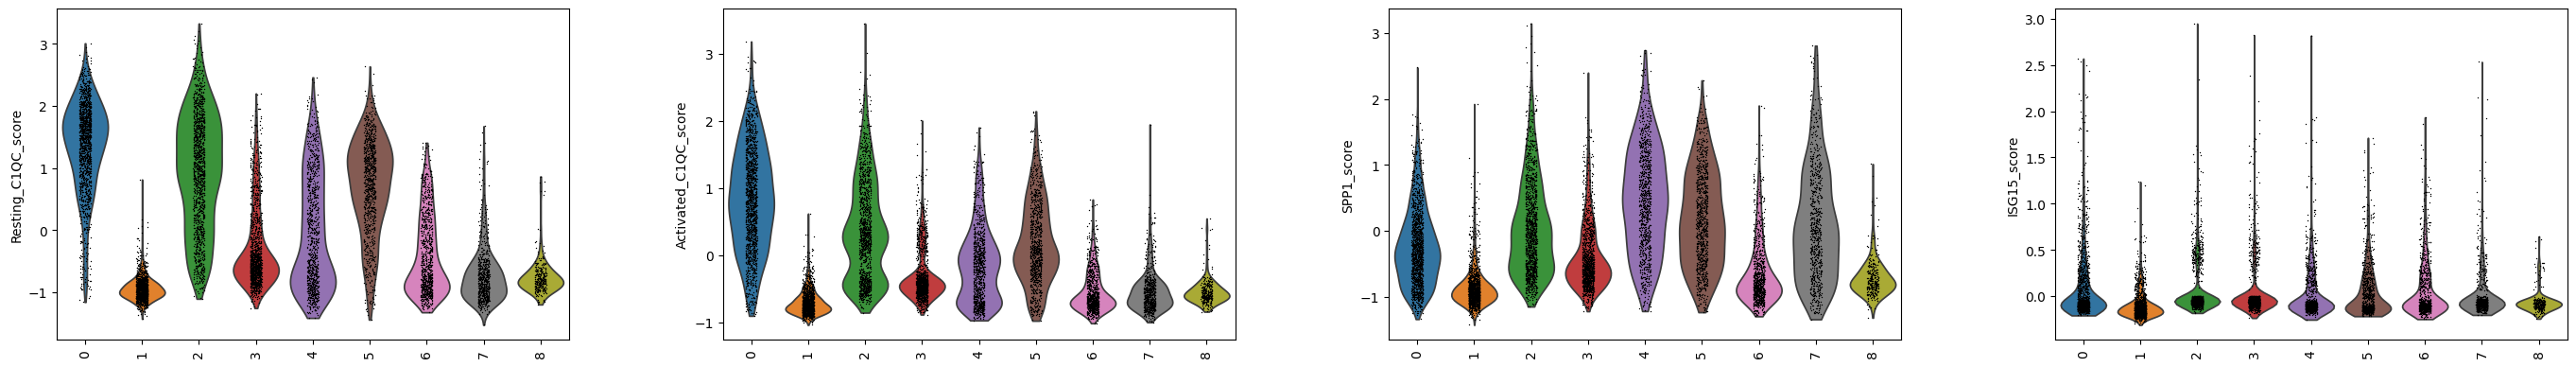

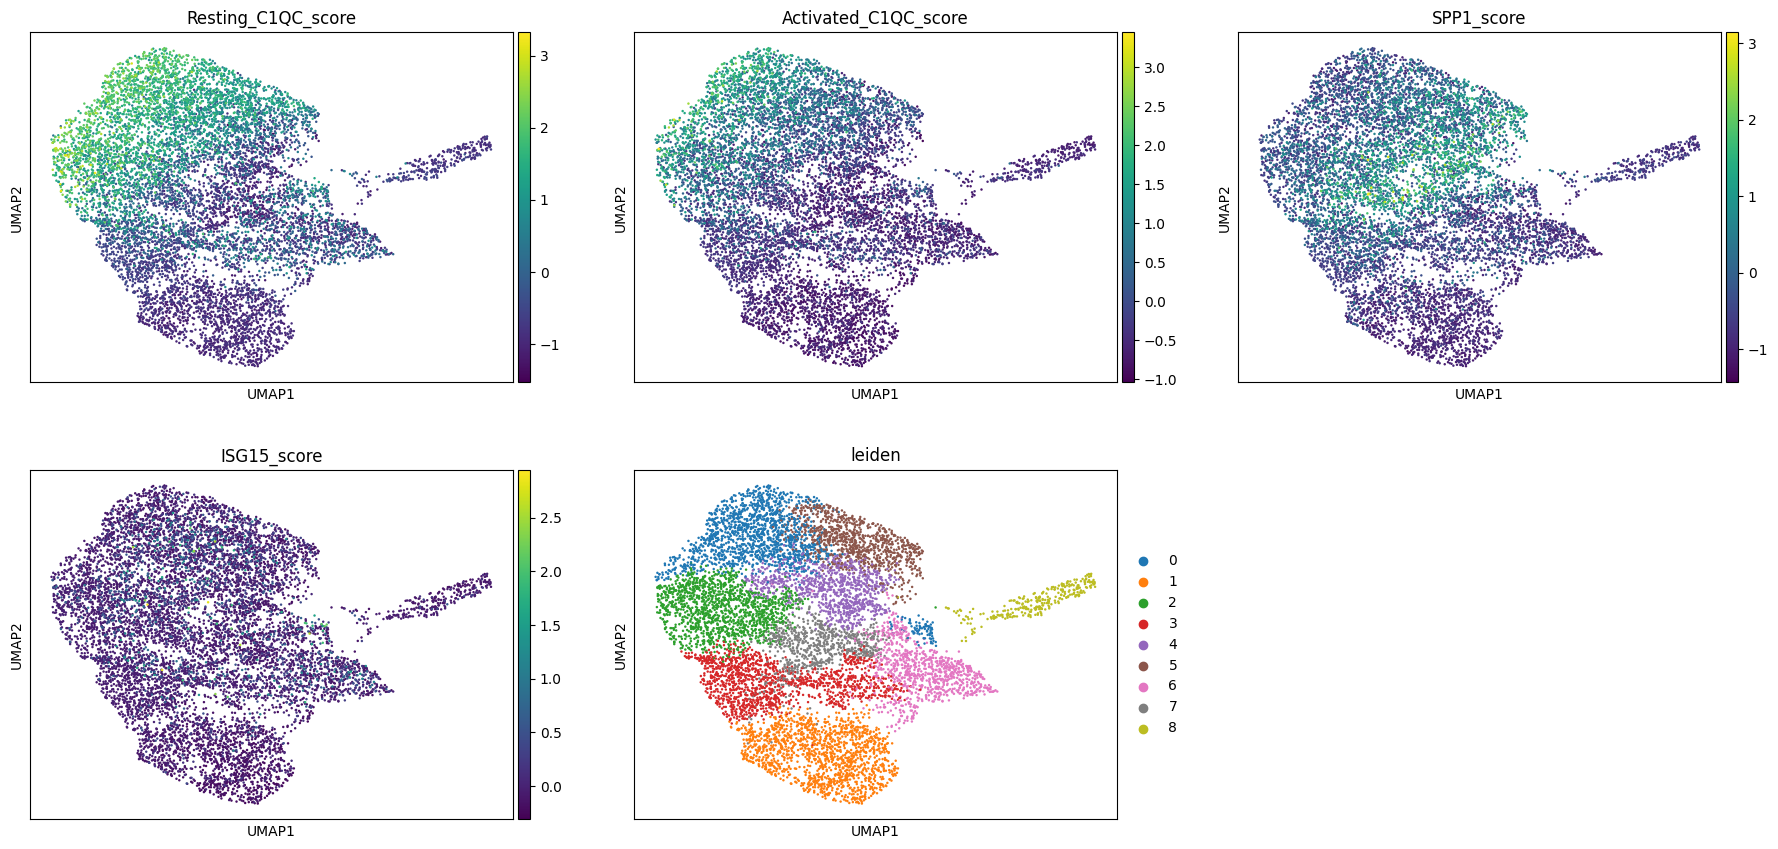

In [35]:
resting_markers = [g for g in resting_c1qc_markers if g in mac.var_names]
activated_markers = [g for g in activated_c1qc_markers if g in mac.var_names]
spp1_markers_valid = [g for g in spp1_markers if g in mac.var_names]
isg15_markers_valid = [g for g in isg15_markers if g in mac.var_names]

print("Resting C1QC+ markers:", resting_markers)
print("Activated C1QC+ markers:", activated_markers)
print("SPP1+ markers:", spp1_markers_valid)
print("ISG15+ markers:", isg15_markers_valid)

if resting_markers:
    sc.tl.score_genes(mac, resting_markers, score_name="Resting_C1QC_score")

if activated_markers:
    sc.tl.score_genes(mac, activated_markers, score_name="Activated_C1QC_score")

if spp1_markers_valid:
    sc.tl.score_genes(mac, spp1_markers_valid, score_name="SPP1_score")

if isg15_markers_valid:
    sc.tl.score_genes(mac, isg15_markers_valid, score_name="ISG15_score")

score_cols = ["Resting_C1QC_score", "Activated_C1QC_score", "SPP1_score", "ISG15_score"]

sc.pl.violin(mac, score_cols, groupby="leiden", rotation=90)
sc.pl.umap(mac, color=score_cols + ["leiden"], ncols=3)

In [36]:
score_cols = ["Resting_C1QC_score", "Activated_C1QC_score", "SPP1_score", "ISG15_score"]
summary = mac.obs.groupby('leiden')[score_cols].mean()
print(summary.round(3))

        Resting_C1QC_score  Activated_C1QC_score  SPP1_score  ISG15_score
leiden                                                                   
0                    1.345                 0.827      -0.242        0.080
1                   -0.944                -0.700      -0.862       -0.101
2                    0.932                 0.377       0.060        0.052
3                   -0.286                -0.307      -0.397        0.033
4                   -0.028                -0.136       0.471        0.029
5                    0.693                 0.189       0.181        0.046
6                   -0.401                -0.536      -0.630        0.066
7                   -0.717                -0.538       0.108        0.015
8                   -0.758                -0.542      -0.713       -0.058


C:\Users\82108\AppData\Local\Temp\ipykernel_3356\47234728.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = mac.obs.groupby('leiden')[score_cols].mean()


### results

이거 분석 다시해야함 지금 이상함

C1QC+ TAM:
- cluster 0: Resting_C1QC_score(1.345), Activated_C1QC_score(0.827) 모두 9개 cluster 중 최고치.  
  SPP1_score는 음수(-0.242)로 가장 명확한 C1QC+ core.  
- cluster 2: Resting_C1QC_score(0.932)로 두 번째로 높고, Activated_C1QC_score(0.377)도 양수.  
  SPP1_score는 0.060으로 거의 0에 가까워 C1QC 쪽으로 판단 -> C1QC+ TAM (tentative)  
- cluster 5: Resting_C1QC_score(0.693), Activated_C1QC_score(0.189)로 cluster 0, 2보다 약하지만
  양수. SPP1_score(0.181)도 함께 양수라 약한 intermediate 성향이 있으나, C1QC score가
  SPP1_score보다 일관되게 높아 C1QC 쪽 tentative로 판단.

SPP1+ TAM:
- cluster 9: dotplot에서 SPP1 가장 크고 진함, ISG15 중간+, C1QC 낮음 -> 가장 명확한 SPP1 core
- cluster 5: dotplot SPP1 중간, violin SPP1_score 중간, UMAP SPP1 high 영역 -> SPP1 TAM 후보 (약함)

ISG15 TAM
- 세 지표 모두에서 유의미한 신호 없음. 단일 암종(NSCLC) 한계로 예상된 결과

Unresolved (2, 3, 4, 7, 8)
- C1QC/SPP1/ISG15 전부 낮음. 세 marker만으로는 판단 불가. monocyte 또는 다른 myeloid subtype 가능성

현재 기준:
- cluster 6, 0 -> C1QC+ TAM
- cluster 1 -> C1QC+ TAM (tentative)
- cluster 9 -> SPP1+ TAM
- cluster 5 -> SPP1+ TAM (tentative)
- ISG15+ TAM은 단일 폐암 데이터에서 독립 cluster로 뚜렷하게 분리되지 않아 annotation하지 않음

이 결과는 C1QC+ TAM / SPP1+ TAM 패턴은 GSE127465 폐암 데이터에서도 관찰되지만, ISG15+ TAM은 pan-cancer 통합 수준에서 더 뚜렷할 수 있음을 시사한다.

tam_subtype
Unknown                  4566
C1QC+ TAM                2346
C1QC+ TAM (tentative)    1471
SPP1+ TAM (tentative)     978
SPP1+ TAM                 206
Name: count, dtype: int64
tam_subtype
Unknown                  47.73
C1QC+ TAM                24.52
C1QC+ TAM (tentative)    15.38
SPP1+ TAM (tentative)    10.22
SPP1+ TAM                 2.15
Name: proportion, dtype: float64


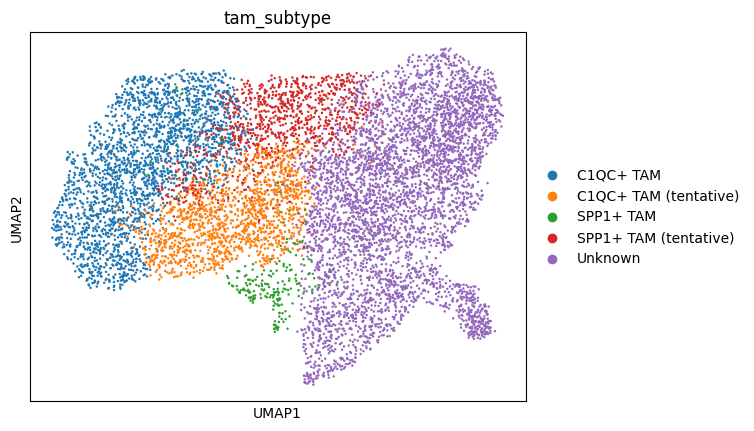

In [36]:
mac.obs['tam_subtype'] = mac.obs['leiden'].map({
    '6': 'C1QC+ TAM',
    '0': 'C1QC+ TAM',
    '1': 'C1QC+ TAM (tentative)',
    '9': 'SPP1+ TAM',
    '5': 'SPP1+ TAM (tentative)',
}).fillna('Unknown')

print(mac.obs['tam_subtype'].value_counts())
print((mac.obs['tam_subtype'].value_counts(normalize=True) * 100).round(2))

sc.pl.umap(mac, color='tam_subtype')

## 6. 중간 결과 저장

다음 notebook(`02_DEG_analysis.ipynb`)에서 DEG 분석을 수행하기 위해 TAM subtype annotation이 추가된 macrophage subset을 저장한다.

In [38]:
mac.write_h5ad(MAC_SUB_H5AD)
print(f'저장 완료: {MAC_SUB_H5AD}')

저장 완료: dataset\GSE127465_mac_subtyped.h5ad
